In [1]:
import pathlib
from argparse import ArgumentParser
import yaml
import torch
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint

/om4/group/mcdermott/user/imgriff/conda_envs_files/torch_11_cuda_11/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys 
sys.path.append('../')
from src.attn_tracking_lightning import AttentionalTrackingModule


In [3]:
path = '../config/attentional_cue/attn_cue_lr_1e-4_bs_64.yaml'
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)

In [4]:
model = AttentionalTrackingModule(config)

In [5]:
!ls ../attn_cue_models/attn_cue_jsin_pilot_no_pretrain_bs_64_lr_1e-4/checkpoints/

epoch=0-step=14999-v1.ckpt  epoch=0-step=34999.ckpt
epoch=0-step=19999-v1.ckpt  epoch=0-step=4999-v1.ckpt
epoch=0-step=19999-v2.ckpt  epoch=0-step=9999.ckpt
epoch=0-step=24999.ckpt     epoch=1-step=100790-v1.ckpt
epoch=0-step=34999-v1.ckpt  epoch=1-step=120790.ckpt


In [6]:
ckpt_path = '../attn_cue_models/attn_cue_jsin_pilot_no_pretrain_bs_64_lr_1e-4/checkpoints/epoch=1-step=120790.ckpt'

ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))

model.load_state_dict(ckpt['state_dict'])


<All keys matched successfully>

In [7]:
attn_params = model.attn_modules

In [8]:
[param for param in attn_params[0].named_parameters()]

[('bias',
  Parameter containing:
  tensor([0.0001], requires_grad=True)),
 ('slope',
  Parameter containing:
  tensor([-1.7379], requires_grad=True)),
 ('threshold',
  Parameter containing:
  tensor([-1.3705], requires_grad=True))]

In [9]:
attn_params[0].bias.item()

0.00010932928853435442

In [10]:
n_attn_blocks = len(attn_params)

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

## Plot attentional filters

In [12]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [13]:
n_attn_blocks

8

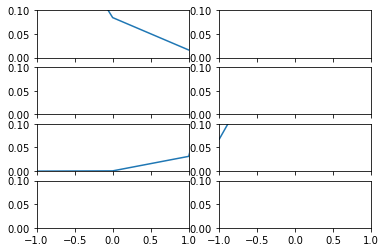

In [26]:
fig, axs = plt.subplots(n_attn_blocks//2, 2, sharex=True)
axs = axs.ravel()
layer_names = [name for name in model._modules['model']._modules.keys() if 'attn' in name]
# layer_names = ['cochleagram'] + layer_names

x = np.arange(-10,11)

for i in range(n_attn_blocks):
    bias = attn_params[i].bias.item()
    slope = attn_params[i].slope.item()
    threshold = attn_params[i].threshold.item()
    
    axs[i].plot(x, bias + (1-bias) * sigmoid((x - threshold) * slope))
#     axs[i].text(12, 0.25, f"bias={bias:.2f}\nslope={slope:.2f}\nthreshold={threshold:.2f}")
#     axs[i].set_title(layer_names[i])
    axs[i].set_ylim(0,0.1)
    axs[i].set_xlim(-1,1)

    
    
# plt.tight_layout()